# Explaining the red noise in the SSH 2km product
**Author**: Ryan Shìjié Dù   
**Created**: October 16th, 2025   
**Last Modified**: March 2nd, 2026   

It is confusing when we plot the along-track spectrum of SWOT SSH, the small scales have a red spectral shape with a -1 slope or slightly steeper. 

At SWOT SSH small scales, the data should be dominated by noise. The noise model suggests the noise should be uncorrelated, that is, spectrally white. The difference between the noise model and the observed spectrum needs to be explained.

In this notebook, we test a hypothesis that the red part of the spectrum is actually just white noise in 2D. It appears red in the along-track spectra of the 2km posting data because of the 2D Hamming filtering used to produce the 2km posting data, and the 1D along-track spectrum calculation. We recover a -1 spectral slope via these two simple ingredients.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from scipy.special import kv, gamma
from scipy.signal.windows import hamming

In [5]:
# Use fft with normalization to ensure that the power spectral density is correctly scaled
def fft(inp):
    return np.fft.fft(inp,norm='forward')

# def ifft(inp):
#     return np.fft.ifft(inp,norm='forward')

def fft2(inp):
    return np.fft.fft2(inp,norm='forward')

def ifft2(inp):
    return np.fft.ifft2(inp,norm='forward')

In [6]:
def matern_spectral_density_1d(f, nu, l=0.1):
    """
    Evaluate the 1D Matérn spectral power density.

    Parameters:
    - f : array-like, frequencies
    - nu : smoothness parameter (ν > 0)
    - l : scale parameter (l > 0)

    Returns:
    - S(f) : spectral density at frequencies f
    """

    f = np.asarray(f)
    prefactor = (2 * nu)**nu * gamma(nu + 0.5) / (np.sqrt(np.pi) * gamma(nu) * l**(2 * nu))
    denominator = ((2 * np.pi * f)**2 + (2 * nu) / l**2)**(nu + 0.5)
    return prefactor / denominator

In [7]:
# Define a region of 500 km (large enough for spectral analysis)
# With 250 m posting
Lx_target = 500 #km
dx, dy = 0.25, 0.25 #km

Nx, Ny = int(Lx_target/dx), int(Lx_target/dx)
Lx, Ly = dx*Nx, dx*Ny

k = np.fft.fftfreq(Nx, d=dx); l = np.fft.fftfreq(Ny, d=dy)
k_mat, l_mat = np.meshgrid(k,l)
Ka_mat = np.sqrt(k_mat**2+l_mat**2)
x = np.arange(-Lx/2,Lx/2,Lx/Nx); y = np.arange(-Ly/2,Ly/2,Ly/Ny)
x_mat, y_mat = np.meshgrid(x,y)

We create a "balanced" signal using a Matern kernel. The important parameter here is the spectral slope at small scales, which we set to be -4. 

We create a white noise spectrum.

The total spectrum is the sum of the two. 

The SSH field is generated from the total spectrum as a Gaussian random field.

In [8]:
# Create a "Balanced" spectrum with a -4 spectral slope at the small scales, the magnitude is hand-picked to match the plot in Zhang and Callies 2025
Bal_spec = matern_spectral_density_1d(Ka_mat, 2, l=100)*2e3
# Create a "Noise" spectrum that is white
Noise_spec = np.ones(Bal_spec.shape)*1e-3*20

Tot_spec = Bal_spec+Noise_spec
Tot_spec[0,0] = 0

In [9]:
# Gerenate the SSH from the total spectrum as a Gaussian random field
SSH_hat = np.repeat(np.array([Tot_spec**0.5]), repeats=1, axis=0)
SSH_hat = SSH_hat * (np.random.normal(0,1,SSH_hat.shape)+1j*np.random.normal(0,1,SSH_hat.shape))/np.sqrt(2)

SSH = np.real( np.fft.ifft2(SSH_hat,norm='forward', axes=(1,2)) )*np.sqrt(2)

In [10]:
# Sample the 2D field to get the along-track spectrum (average over the cross-track direction)
SSH_alongtrack_spec = np.mean(np.abs(np.fft.fft(SSH,norm='forward', axis=2))**2, axis=(0,1))

We plot the along track spectrum and see that the small scale is white, it is dominated by noise as expected.

(0.03, 70000.0)

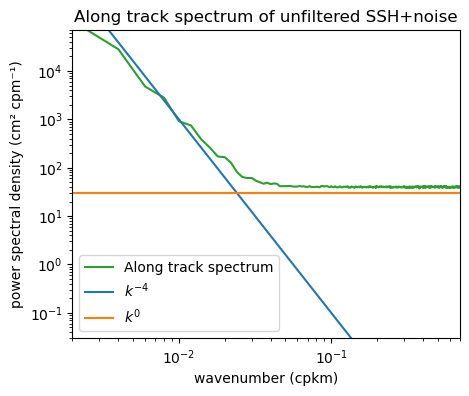

In [11]:
plt.figure(figsize=(5, 4))

plt.loglog(k[k>0],SSH_alongtrack_spec[k>0], color='C2', label='Along track spectrum')
plt.loglog(k[k>0],k[k>0]**(-4)/1e5,'-', color='C0', label='$k^{-4}$')
plt.loglog(k[k>0],k[k>0]**(0)*30,'-', color='C1', label='$k^{0}$')

plt.xlabel('wavenumber (cpkm)')
plt.ylabel('power spectral density (cm² cpm⁻¹)')
plt.legend(loc='lower left')
plt.title("Along track spectrum of unfiltered SSH+noise")

plt.xlim([2e-3,7e-1])
plt.ylim([3e-2,7e4])

Now we convolve the SSH using a 17-point 2D Hamming filter to produce a 2km posting data, just like the SWOT processing.

This is done by multiplying the total spectrum with the spectrum of the Hamming filter.

In [18]:
# Create the 2D 17 point Hamming window filter used in SWOT processing to create the 2km data
center_idx = len(x) // 2
window_size = 17
half_window = window_size // 2

# Create 1D Hamming window centered at (0,0)
hamm_1d = np.zeros_like(x)
hamm_1d[center_idx - half_window:center_idx + half_window + 1] = hamming(window_size)
# Create 2D filter using outer product
hamm_filt2d = np.outer(hamm_1d, hamm_1d)

# Compute spectrum
hamm_filt_spec = np.abs(fft2(hamm_filt2d))**2
hamm_filt_spec /= hamm_filt_spec[0,0]

In [19]:
# Gerenate the SSH from the total Hamming filtered spectrum as a Gaussian random field
# This should be equivelent to convolution of the Hamming filter with the previous SSH field above
SSH_filt_hat = np.repeat(np.array([(Tot_spec*hamm_filt_spec)**0.5]), repeats=1, axis=0)
SSH_filt_hat = SSH_filt_hat * (np.random.normal(0,1,SSH_filt_hat.shape)+1j*np.random.normal(0,1,SSH_filt_hat.shape))/np.sqrt(2)

SSH_filt = np.real( np.fft.ifft2(SSH_filt_hat,norm='forward', axes=(1,2)) )*np.sqrt(2)

In [20]:
# Sample the 2D field to get the along-track spectrum (average over the cross-track direction)
SSH_filt_alongtrack_spec = np.mean(np.abs(np.fft.fft(SSH_filt,norm='forward', axis=2))**2, axis=(0,1))

We plot the along-track spectrum and see that the "noise" now appears red. This is entirely due to the 2D Hamming filter + 1D along-track spectrum calculation.

(0.03, 70000.0)

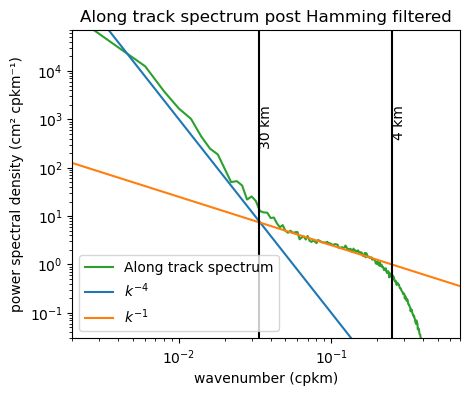

In [21]:
plt.figure(figsize=(5, 4))

plt.loglog(k[k>0],SSH_filt_alongtrack_spec[k>0], color='C2', label='Along track spectrum')

plt.loglog(k[k>0],k[k>0]**(-4)/1e5,'-', color='C0', label='$k^{-4}$')
plt.loglog(k[k>0],k[k>0]**(-1)/4,'-', color='C1', label='$k^{-1}$')

plt.axvline(1/30, color='black')
plt.axvline(1/4, color='black')

plt.text(1/30, 2e3, '30 km', rotation=90, verticalalignment='top')
plt.text(1/4, 2e3, '4 km', rotation=90, verticalalignment='top')

plt.xlabel('wavenumber (cpkm)')
plt.ylabel('power spectral density (cm² cpkm⁻¹)')
plt.legend(loc=3)
plt.title("Along track spectrum post Hamming filtered")

plt.xlim([2e-3,7e-1])
plt.ylim([3e-2,7e4])

We have recreated a -1 spectral slope with minimal ingredients. One can argue no physics is used, which I think is desirable in this case.

In real SWOT data the spectral slope can be steeper. I have not been able to recreate that using these minimal ingredients. I hypothesize we need to add more ingredients:
- If the SSH noise is proportional to SWH, SWH's spectral behavior can matter for the ultimate slope of the SSH noise. Basically, the SSH noise might not be white in 2D.
- The real SWOT along-track spectrum is calculated by averaging across swath. The SSH noise can depend on the cross-track distance. Therefore, we are averaging over different noise levels. This can make the ultimate average appear more red.

More experiements along these lines should be easy to do.